# Homework 4

## Andre Sae

## Linear Regression with Gradient Descent

Your task in this assignment is to implement Multiple Linear Regression. 

We will use the New York City Taxi trip reports in the Year 2013. 
The dataset was released under the FOIL (The Freedom of Information Law) and made public by Chris Whong (\url{https://chriswhong.com/open-data/foil_nyc_taxi/}).



# Taxi Data Set
The data set itself is a simple text file. Each taxi trip report is a different line in the file. Among other things, each trip report 
includes the starting point, the drop-off point, corresponding timestamps, and information related to the payment. The data are reported 
by the time that the trip ended, i.e., upon arriving in the order of the drop-off timestamps. 
The attributes present on each line of the file are, in order:



| index | **Attribute** | **Description** |
| --- | --- | --- |
| 0 | medallion           |  an md5sum of the identifier of the taxi - vehicle bound (Taxi ID)  | 
| 1 | hack license       |  an md5sum of the identifier for the taxi license (Driver ID)  |  
| 2 | pickup datetime    | time when the passenger(s) were picked up  |  
| 3 | dropoff datetime   | time when the passenger(s) were dropped off  | 
| 4 | trip time in secs | duration of the trip  |  
| 5 | trip distance | trip distance in miles  |  
| 6 | pickup longitude | longitude coordinate of the pickup location  |  
| 7 | pickup latitude | latitude coordinate of the pickup location  |  
| 8 | dropoff longitude | longitude coordinate of the drop-off location   |  
| 9 | dropoff latitude | latitude coordinate of the drop-off location  | 
| 10 | payment type | the payment method -credit card or cash  |  
| 11 | fare amount | fare amount in dollars  |  
| 12 | surcharge | surcharge in dollars  |  
| 13 | mta tax | tax in dollars  |  
| 14 | tip amount | tip in dollars  |  
| 15 | tolls amount | bridge and tunnel tolls in dollars  |  
| 16 | total amount | total paid amount in dollars  |  




The data files are in comma separated values (CSV) format. Example lines from the file are:

07290D3599E7A0D62097A346EFCC1FB5,E7750A37CAB07D0DFF0AF7E3573AC141,\\
2013-01-01,00:00:00,2013-01-01 00:02:00,120,0.44,-73.956528,40.716976,-73.962440,\\
40.715008,CSH,3.50,0.50,0.50,0.00,0.00,4.50

22D70BF00EEB0ADC83BA8177BB861991,3FF2709163DE7036FCAA4E5A3324E4BF,\\
2013-01-01,00:02:00,2013-01-01 00:02:00,0,0.00,0.000000,0.000000,0.000000,0.000000,\\
CSH,27.00,0.00,0.50,0.00,0.00,27.50

0EC22AAF491A8BD91F279350C2B010FD,778C92B26AE78A9EBDF96B49C67E4007,\\
2013-01-01,00:01:00,2013-01-01 00:03:00,120,0.71,-73.973145,40.752827,-73.965897\\
73.965897,40.760445,CSH,4.00,0.50,0.50,0.00,0.00,5.00



In [1]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import ipympl

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# %matplotlib widget


In [2]:
df = pd.read_csv('nyc-taxi-data.csv.bz2', header=None)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,07290D3599E7A0D62097A346EFCC1FB5,E7750A37CAB07D0DFF0AF7E3573AC141,2013-01-01 00:00:00,2013-01-01 00:02:00,120,0.44,-73.956528,40.716976,-73.962440,40.715008,CSH,3.5,0.5,0.5,0.00,0.0,4.50
1,22D70BF00EEB0ADC83BA8177BB861991,3FF2709163DE7036FCAA4E5A3324E4BF,2013-01-01 00:02:00,2013-01-01 00:02:00,0,0.00,0.000000,0.000000,0.000000,0.000000,CSH,27.0,0.0,0.5,0.00,0.0,27.50
2,0EC22AAF491A8BD91F279350C2B010FD,778C92B26AE78A9EBDF96B49C67E4007,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.71,-73.973145,40.752827,-73.965897,40.760445,CSH,4.0,0.5,0.5,0.00,0.0,5.00
3,1390FB380189DF6BBFDA4DC847CAD14F,BE317B986700F63C43438482792C8654,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.48,-74.004173,40.720947,-74.003838,40.726189,CSH,4.0,0.5,0.5,0.00,0.0,5.00
4,3B4129883A1D05BE89F2C929DE136281,7077F9FD5AD649AEACA4746B2537E3FA,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.61,-73.987373,40.724861,-73.983772,40.730995,CRD,4.0,0.5,0.5,0.00,0.0,5.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,A0AFE6B722F15B7A0FDFEEA954BE316A,93D505C96BD248DC390FD47F747D762D,2013-01-01 03:44:00,2013-01-01 03:46:00,120,0.79,-73.963593,40.710941,-74.027779,40.629894,CSH,4.5,0.5,0.5,0.00,0.0,5.50
49996,A0DEAEC3D5592AE94B876356F12F8158,6A35995FBD5399AB131B89623C344782,2013-01-01 03:35:00,2013-01-01 03:46:00,660,2.41,-73.955833,40.768272,-73.987724,40.775490,CRD,10.0,0.5,0.5,2.10,0.0,13.10
49997,A154EFA0695A29423B078C7F5D5B2CB5,F38E7C3381F28C9B3E51C0B6DDBDF68A,2013-01-01 03:40:00,2013-01-01 03:46:00,360,1.63,-73.963951,40.709934,-73.949364,40.695381,CRD,7.0,0.5,0.5,2.25,0.0,10.25
49998,A2B97CECFEA4C8DE45D8FC251E80AF1D,68AE01DDBDEDDFF772905561744A1072,2013-01-01 03:34:00,2013-01-01 03:46:00,720,4.04,-73.952759,40.776524,-73.983093,40.738796,CRD,14.5,0.5,0.5,3.00,0.0,18.50


## Task - 1
The dataset is a real-world dataset and many records are incorrect and wrong. Your task is first to describe at least 4 data clean up tasks and implement them on this data set.

For example, you can define to remove lines with the following property, if a taxi trip (one of the data rows) has a travel distance less than 1 mile and total amount of more than 20 dollar, then it is an wrong record. 

Another example is that you would expect to have a float number (e.g., index 12 to 16) and then you got a String in that position. You can remove such lines from your data. 

Perform the following cleanup tasks:
1. Add column headers based on the description above (no need to describe).
2. Drop rows with a travel distance < 1 mile and a total fare > $20 (no need to describe). Both conditions need to be met.
3. Your own task (please describe your task in a comment/cell).
4. Your own task (please describe your task in a comment/cell).

**(4 points)**

In [3]:
# Your code here

df = df.rename(columns={
    0: 'medallion',
    1: 'hack license',
    2: 'pickup datetime',
    3: 'dropoff datetime',
    4: 'trip time in secs',
    5: 'trip distance',
    6: 'pickup longitude',
    7: 'pickup latitude',
    8: 'dropoff longitude',
    9: 'dropoff latitude',
    10: 'payment type',
    11: 'fare amount',
    12: 'surcharge',
    13: 'mta tax',
    14: 'tip amount',
    15: 'tolls amount',
    16: 'total amount'
})

df

,medallion,hack license,pickup datetime,dropoff datetime,trip time in secs,trip distance,pickup longitude,pickup latitude,dropoff longitude,dropoff latitude,payment type,fare amount,surcharge,mta tax,tip amount,tolls amount,total amount
0,07290D3599E7A0D62097A346EFCC1FB5,E7750A37CAB07D0DFF0AF7E3573AC141,2013-01-01 00:00:00,2013-01-01 00:02:00,120,0.44,-73.956528,40.716976,-73.962440,40.715008,CSH,3.5,0.5,0.5,0.00,0.0,4.50
1,22D70BF00EEB0ADC83BA8177BB861991,3FF2709163DE7036FCAA4E5A3324E4BF,2013-01-01 00:02:00,2013-01-01 00:02:00,0,0.00,0.000000,0.000000,0.000000,0.000000,CSH,27.0,0.0,0.5,0.00,0.0,27.50
2,0EC22AAF491A8BD91F279350C2B010FD,778C92B26AE78A9EBDF96B49C67E4007,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.71,-73.973145,40.752827,-73.965897,40.760445,CSH,4.0,0.5,0.5,0.00,0.0,5.00
3,1390FB380189DF6BBFDA4DC847CAD14F,BE317B986700F63C43438482792C8654,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.48,-74.004173,40.720947,-74.003838,40.726189,CSH,4.0,0.5,0.5,0.00,0.0,5.00
4,3B4129883A1D05BE89F2C929DE136281,7077F9FD5AD649AEACA4746B2537E3FA,2013-01-01 00:01:00,2013-01-01 00:03:00,120,0.61,-73.987373,40.724861,-73.983772,40.730995,CRD,4.0,0.5,0.5,0.00,0.0,5.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,A0AFE6B722F15B7A0FDFEEA954BE316A,93D505C96BD248DC390FD47F747D762D,2013-01-01 03:44:00,2013-01-01 03:46:00,120,0.79,-73.963593,40.710941,-74.027779,40.629894,CSH,4.5,0.5,0.5,0.00,0.0,5.50
49996,A0DEAEC3D5592AE94B876356F12F8158,6A35995FBD5399AB131B89623C344782,2013-01-01 03:35:00,2013-01-01 03:46:00,660,2.41,-73.955833,40.768272,-73.987724,40.775490,CRD,10.0,0.5,0.5,2.10,0.0,13.10
49997,A154EFA0695A29423B078C7F5D5B2CB5,F38E7C3381F28C9B3E51C0B6DDBDF68A,2013-01-01 03:40:00,2013-01-01 03:46:00,360,1.63,-73.963951,40.709934,-73.949364,40.695381,CRD,7.0,0.5,0.5,2.25,0.0,10.25
49998,A2B97CECFEA4C8DE45D8FC251E80AF1D,68AE01DDBDEDDFF772905561744A1072,2013-01-01 03:34:00,2013-01-01 03:46:00,720,4.04,-73.952759,40.776524,-73.983093,40.738796,CRD,14.5,0.5,0.5,3.00,0.0,18.50


In [4]:
# Your code here
print(df.size)

df = df[(df[df.columns[5]] > 1)]
df = df[(df[df.columns[11]]  < 20)]

print(df.size)


850000
571642


In [5]:
# Your code here

In [6]:
# Your code here

## Task - 2
Use the cleaned dataset from task 1.
Find out the correlations between trip distance, travel time and fare amount. Visualize the correlations in form of Scatterplot matrix. 
Describe the correlations between them. **(4 points)**

In [7]:
# Your code here

## Task - 3
Use the cleaned dataset from task 1.
We want to find a simple line to our data (distance, money). 
We want to use trip distance, and fare amount. Use the **Scikit-learn** library to fit a line into the data. **(2 points)**

* Provide the Regression Cofficients of your model
* Write down your linear regression equation. 
* Use your model to predict the fare amount for a 3 miles trip. 

A visualization of the model is not required, but it would be nice to have and good practice.

In [8]:
# Your code here

## Task - 4
Fit a Multiple Linear Regression hyperplane into this data. We are interested to predict total amount out of trip distance, tavel time. **(4 points)**
Use the **Scikit-learn** library.

* Provide the Regression Cofficients of your model
* Write down your Multiple Linear Regression equation. 
* Use your model to predict the total amount for a 3 miles trip and 6 min travel time. 

A visualization of the model is not required, but it would be nice to have and good practice.

Regression Coefficent
[2.11368606 0.00615834]
Intercept Values
3.2463617638733933
Predict the total amount for a 3 miles trip and 6 min travel time.
[10.69592028]
Visualization
(array([[1.        , 1.66666667, 2.33333333, 3.        , 3.66666667,
        4.33333333, 5.        , 5.66666667, 6.33333333, 7.        ],
       [1.        , 1.66666667, 2.33333333, 3.        , 3.66666667,
        4.33333333, 5.        , 5.66666667, 6.33333333, 7.        ],
       [1.        , 1.66666667, 2.33333333, 3.        , 3.66666667,
        4.33333333, 5.        , 5.66666667, 6.33333333, 7.        ],
       [1.        , 1.66666667, 2.33333333, 3.        , 3.66666667,
        4.33333333, 5.        , 5.66666667, 6.33333333, 7.        ],
       [1.        , 1.66666667, 2.33333333, 3.        , 3.66666667,
        4.33333333, 5.        , 5.66666667, 6.33333333, 7.        ],
       [1.        , 1.66666667, 2.33333333, 3.        , 3.66666667,
        4.33333333, 5.        , 5.66666667, 6.33333333, 7.        ],


/home/andre/.local/src/cs329e_analysis/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


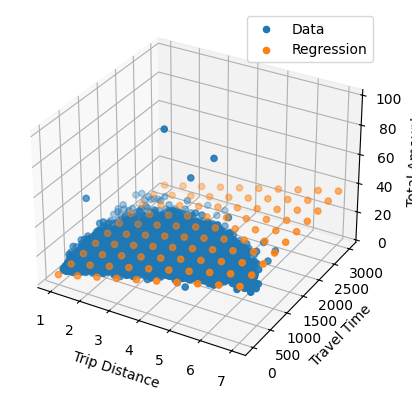

In [6]:
# Your code here

from sklearn.linear_model import LinearRegression

trip_distance = df[df.columns[5]]

travel_time = df[df.columns[4]]

total_amount = df[df.columns[16]]

x = pd.concat([trip_distance, travel_time], axis=1)

y = total_amount

model = LinearRegression()

model.fit(x, y)

print("Regression Coefficent")
print(model.coef_)

print("Intercept Values")
print(model.intercept_)

print("Predict the total amount for a 3 miles trip and 6 min travel time.")
print(model.predict([[3, 180]]))

print("Visualization")

figure = plt.figure()
ax = figure.add_subplot(projection='3d')

ax.scatter(trip_distance, travel_time, total_amount, label='Data')

x_1 = np.linspace(1, 7, num=10)
x_2 = np.linspace(0, 3000, num=10)

x_grid = np.meshgrid(x_1, x_2)

print(x_grid)

y_pred = model.coef_[0] * x_1 + model.coef_[1] * x_2 + model.intercept_


ax.scatter(x_grid[0], x_grid[1], y_pred, label='Regression')

ax.set_xlabel("Trip Distance")
ax.set_ylabel("Travel Time")
ax.set_zlabel("Total Amount")

plt.legend()
plt.show()


## Task - 5 - Gradient Descent
Implement the gradient descent optimization to find the optimal parameters for our Simple Linear Regression model of task 3. **(6 points)**

* Define and set your learning rate (start with a very small number and increase it if your GC works)
* Instantiate all coefficients from zero
* Run maximum 400 interations. You can stop if your cost converge with a precision of 0.01 
* Print and visualize the optimization costs
* Provide the Regression Coefficients of your model after stop or convergance. 

Please note that a visualization **is** required, unlike in Task 3 and 4.

Cost Function: 96.54253874977697
Cost Function: 79.10011271311
Cost Function: 64.91472578452763
Cost Function: 53.378013173020456
Cost Function: 43.99524385529186
Cost Function: 36.36409542499783
Cost Function: 30.157393494378855
Cost Function: 25.109075127010453
Cost Function: 21.002774099104816
Cost Function: 17.66253826956044
Cost Function: 14.945280811560538
Cost Function: 12.734641445361216
Cost Function: 10.935994304359475
Cost Function: 9.472388259862857
Cost Function: 8.281245534708276
Cost Function: 7.311676968296894
Cost Function: 6.522298751444039
Cost Function: 5.879456963706891
Cost Function: 5.355783741561867
Cost Function: 4.929023133566498
Cost Function: 4.581076268862198
Cost Function: 4.297224874445257
Cost Function: 4.06549982822547
Cost Function: 3.8761676572766612
Cost Function: 3.721312950816343
Cost Function: 3.5944987724249127
Cost Function: 3.4904905023700485
Cost Function: 3.4050312622064527
Cost Function: 3.3346592868250067
Cost Function: 3.2765594087720658
C

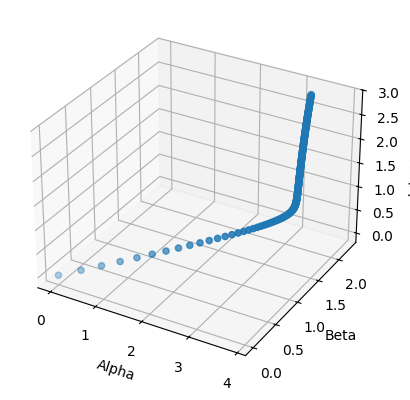

In [ ]:
# Your code here

import math

def linear_cost_fn(alpha, beta, intercept, y, x_0, x_1): 
    if len(x_0) != len(x_1) or len(x_0) != len(y): raise Exception("x_0, x_1, and y array size should match.")

    return (1 / (2 * len(x_0))) * ((y - linear_predict(alpha, beta, intercept, x_0, x_1)) ** 2).sum()

def linear_grad_cost_fn(alpha, beta, intercept, y, x_0, x_1):
    
    grad_alpha = (1 / (2 * len(x_0))) * 2 * ((y - linear_predict(alpha, beta, intercept, x_0, x_1)) * x_0).sum() * (-1)
    grad_beta = (1 / (2 * len(x_0))) * 2 * ((y - linear_predict(alpha, beta, intercept, x_0, x_1)) * x_1).sum() * (-1)
    grad_intercept = (1 / (2 * len(x_0))) * 2 * ((y - linear_predict(alpha, beta, intercept, x_0, x_1))).sum() * (-1)


    return np.array([grad_alpha, grad_beta, grad_intercept])

def linear_fit(l_rate, y, x_0, x_1, alpha_list, beta_list, intercept_list):

    alpha = 0
    beta = 0
    intercept = 0
    iteration_count = 0

    while(linear_cost_fn(alpha, beta, intercept, y, x_0, x_1) > 0.01 and iteration_count < 401):
        print("Cost Function: " + str(linear_cost_fn(alpha, beta, intercept, y, x_0, x_1)))
        alpha_list.append(alpha)
        beta_list.append(beta)
        intercept_list.append(intercept)
        alpha, beta, intercept = np.array([alpha, beta, intercept]) - l_rate * linear_grad_cost_fn(alpha, beta, intercept, y, x_0, x_1)
        iteration_count += 1
        
    
    if iteration_count >= 400: 
        print("Gradient Descent did not converge.")
    else:  
        print("Model has converged within the acceptable threshold of 0.01 value.")
    return (alpha, beta, intercept)

def linear_predict(alpha, beta, intercept, x_0, x_1):
    return alpha * x_0 + beta * x_1 + intercept


l_rate = 0.01

alphas = []
betas = []
intercepts = []

alpha, beta, intercept = linear_fit(l_rate, y.to_numpy(), trip_distance.to_numpy() , travel_time.to_numpy() / 1000, alphas, betas, intercepts)

print("Linear Equation = alpha * x_0 + beta * x_1 + intercept")
print("Alpha: " + str(alpha))
print("Beta: " + str(beta / 1000))
print("Intercept: " + str(intercept))

figure = plt.figure()
ax = figure.add_subplot(projection='3d')

ax.scatter(alphas, np.array(betas) * (1/1000), intercepts)

ax.set_xlabel("Alpha")
ax.set_ylabel("Beta")
ax.set_zlabel("Intercepts")

plt.show()

In [ ]:
c